# Klasični modeli, podešavanje metaparametara i regularizacija

Predikcija srčane slabosti primenom metoda mašinskog učenja. U ovoj svesci učimo šest klasičnih modela, svaki u po dve varijante: prvo bez ikakve regularizacije, a zatim sa regularizacijom čije metaparametre biramo na validacionom skupu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import svm
from sklearn import neighbors
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics

In [3]:
import xgboost

In [4]:
np.random.seed(7)

# Učitavanje i pretprocesiranje skupa podataka

Ponavljamo korake koje smo obrazložili u prvoj svesci: učitavamo podatke, uvodimo atribut <code>Cholesterol_izmeren</code>, nule u kolonama <code>Cholesterol</code> i <code>RestingBP</code> zamenjujemo medijanom i transformišemo kategoričke atribute.

In [5]:
data = pd.read_csv('../data/heart.csv')

In [6]:
data['Cholesterol_izmeren'] = (data['Cholesterol'] != 0).astype(int)

In [7]:
data['Cholesterol'] = data['Cholesterol'].replace(0, data.loc[data['Cholesterol'] != 0, 'Cholesterol'].median())

In [8]:
data['RestingBP'] = data['RestingBP'].replace(0, data.loc[data['RestingBP'] != 0, 'RestingBP'].median())

In [9]:
data = pd.get_dummies(data, drop_first=True, dtype=int)

In [10]:
data.shape

(918, 17)

Ciljna promenljiva je <code>HeartDisease</code>, a sve ostale kolone su atributi.

In [11]:
x = data.drop(labels=['HeartDisease'], axis=1)
y = data['HeartDisease']

In [12]:
x.shape

(918, 16)

In [13]:
y.shape

(918,)

# Podela skupa podataka na skupove za treniranje, validaciju i testiranje

Kada želimo da odredimo optimalne vrednosti metaparametara, iz skupa za treniranje izdvajamo manji skup podataka koji zovemo validacionim skupom. Nad njim proveravamo kako se ponašaju modeli naučeni za različite vrednosti metaparametara i biramo one metaparametre koji daju najbolji model. Prvo podatke delimo na skup za treniranje i skup za testiranje u razmeri 8:2. Zatim iz trening skupa izdvajamo validacioni skup tako da 80% instanci ostane za treniranje. Vrednost parametra <code>stratify</code> postavljamo na niz vrednosti ciljne promenljive, a <code>random_state</code> parametar na vrednost 7.

In [14]:
x_train_validation, x_test, y_train_validation, y_test = model_selection.train_test_split(x, y, test_size=0.2, stratify=y, random_state=7)

In [15]:
x_train, x_validation, y_train, y_validation = model_selection.train_test_split(x_train_validation, y_train_validation, train_size=0.8, stratify=y_train_validation, random_state=7)

In [16]:
x_train.shape

(587, 16)

In [17]:
x_validation.shape

(147, 16)

In [18]:
x_test.shape

(184, 16)

# Standardizacija podataka

Vršimo standardizaciju atributa.

In [19]:
scaler = preprocessing.StandardScaler()

In [20]:
scaler.fit(x_train)

StandardScaler()

In [21]:
x_train = scaler.transform(x_train)
x_validation = scaler.transform(x_validation)
x_test = scaler.transform(x_test)

Standardizacija se vrši zajedno nad skupovima za treniranje, validaciju i testiranje, ali se parametri standardizacije (prosek i varijansa) izračunavaju samo na osnovu instanci skupa za treniranje!

# Modeli bez regularizacije

Prvo učimo šest modela bez regularizacije, da bismo videli koliko se preprilagođavaju skupu za treniranje:

* logistička regresija bez kazne nad koeficijentima, što se postiže vrednošću <code>C</code> = beskonačno
* kernelizovani SVM sa ogromnim <code>C</code>
* KNN sa jednim susedom, gde je svaka instanca sama svoj sused
* slučajna šuma sa stablima neograničene dubine
* AdaBoost čiji je bazni model stablo neograničene dubine
* XGBoost sa dubokim stablima, velikim korakom učenja i isključenom kaznom

In [22]:
modeli_bez_regularizacije = {
    'Logistička regresija': linear_model.LogisticRegression(C=np.inf, max_iter=5000),
    'SVM (RBF)': svm.SVC(kernel='rbf', C=1000000),
    'KNN': neighbors.KNeighborsClassifier(n_neighbors=1),
    'Slučajna šuma': ensemble.RandomForestClassifier(n_estimators=300, max_depth=None, max_features=None, random_state=7),
    'AdaBoost': ensemble.AdaBoostClassifier(estimator=tree.DecisionTreeClassifier(max_depth=None, random_state=7), n_estimators=200, random_state=7),
    'XGBoost': xgboost.XGBClassifier(n_estimators=500, max_depth=8, learning_rate=0.3, reg_lambda=0)
}

Svaki model treniramo na skupu za treniranje i računamo tačnost na skupu za treniranje i na validacionom skupu.

In [23]:
train_scores = []
validation_scores = []

for naziv, model in modeli_bez_regularizacije.items():
    model.fit(x_train, y_train)

    train_scores.append(model.score(x_train, y_train))
    validation_scores.append(model.score(x_validation, y_validation))

In [24]:
rezultati_bez_regularizacije = pd.DataFrame({'trening': train_scores, 'validacija': validation_scores},
                                            index=modeli_bez_regularizacije.keys())
rezultati_bez_regularizacije

,trening,validacija
Logistička regresija,0.88075,0.884354
SVM (RBF),1.00000,0.816327
KNN,1.00000,0.857143
Slučajna šuma,1.00000,0.870748
AdaBoost,1.00000,0.816327
XGBoost,1.00000,0.897959


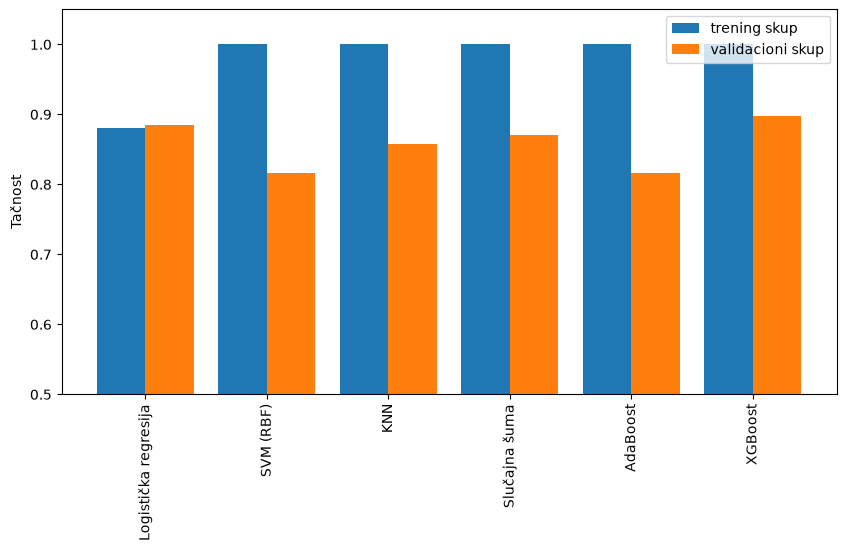

In [25]:
plt.figure(figsize=(10, 5))
plt.bar(np.arange(6) - 0.2, train_scores, width=0.4, label='trening skup')
plt.bar(np.arange(6) + 0.2, validation_scores, width=0.4, label='validacioni skup')
plt.xticks(np.arange(6), modeli_bez_regularizacije.keys(), rotation='vertical')
plt.ylabel('Tačnost')
plt.ylim(0.5, 1.05)
plt.legend(loc='best')
plt.show()

Rezultat je očekivan. Dakle, pet od šest modela ima tačnost 1.00 na skupu za treniranje, što znači da su ga naučili napamet, dok na validacionom skupu padaju osetno niže. Razlika između te dve tačnosti je upravo mera preprilagođavanja.

# Podešavanje metaparametara

Sada za svaki algoritam tražimo vrednosti metaparametara koje daju najbolji model. Postupak je uvek isti: model treniramo na skupu za treniranje za različite vrednosti metaparametara, ocenjujemo ga na validacionom skupu i biramo one vrednosti za koje je ocena najbolja. Kao meru kvaliteta koristimo F1 meru, jer su nam podjednako važni i preciznost i odziv.

## Logistička regresija

Kod logističke regresije podešavamo vrednost regularizacionog parametra <code>C</code>. 

In [26]:
Cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

best_C = None
best_f1_score = 0

for C in Cs:
    model = linear_model.LogisticRegression(C=C, max_iter=5000)
    model.fit(x_train, y_train)

    y_validation_predicted = model.predict(x_validation)
    f1_score = metrics.f1_score(y_validation, y_validation_predicted)

    if f1_score > best_f1_score:
        best_C = C
        best_f1_score = f1_score

In [27]:
print('Najbolji f1-score na validacionom skupu je: ', best_f1_score)

Najbolji f1-score na validacionom skupu je:  0.9024390243902439


In [28]:
print('Najbolji metaparametar C = {}'.format(best_C))

Najbolji metaparametar C = 1


In [29]:
model_logisticka = linear_model.LogisticRegression(C=best_C, max_iter=5000)
model_logisticka.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",5000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Kernelizovani SVM

Kod kernelizovanog SVM-a podešavamo vrednost regularizacionog parametra <code>C</code> i širinu Gausovog kernela <code>gamma</code>.

In [67]:
Cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
gammas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

best_C = None
best_gamma = None
best_f1_score = 0

for C in Cs:
    for gamma in gammas:
        model = svm.SVC(kernel='rbf', gamma=gamma, C=C)
        model.fit(x_train, y_train)

        y_validation_predicted = model.predict(x_validation)
        f1_score = metrics.f1_score(y_validation, y_validation_predicted)

        if f1_score > best_f1_score:
            best_C = C
            best_gamma = gamma
            best_f1_score = f1_score

In [70]:
print('Najbolji f1-score na validacionom skupu je: ', best_f1_score)

Najbolji f1-score na validacionom skupu je:  0.9090909090909091


In [73]:
print('Najbolji metaparametri C = {} i gamma = {}'.format(best_C, best_gamma))

Najbolji metaparametri C = 1 i gamma = 0.1


In [74]:
model_svm = svm.SVC(kernel='rbf', gamma=best_gamma, C=best_C)
model_svm.fit(x_train, y_train)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## KNN

Kod KNN modela podešavamo broj suseda i način na koji se susedi ponderišu.

In [75]:
ks = [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41]
weights = ['uniform', 'distance']

best_k = None
best_weight = None
best_f1_score = 0

for k in ks:
    for weight in weights:
        model = neighbors.KNeighborsClassifier(n_neighbors=k, weights=weight)
        model.fit(x_train, y_train)

        y_validation_predicted = model.predict(x_validation)
        f1_score = metrics.f1_score(y_validation, y_validation_predicted)

        if f1_score > best_f1_score:
            best_k = k
            best_weight = weight
            best_f1_score = f1_score

In [76]:
print('Najbolji f1-score na validacionom skupu je: ', best_f1_score)

Najbolji f1-score na validacionom skupu je:  0.9079754601226994


In [77]:
print('Najbolji metaparametri k = {} i weights = {}'.format(best_k, best_weight))

Najbolji metaparametri k = 3 i weights = uniform


In [78]:
model_knn = neighbors.KNeighborsClassifier(n_neighbors=best_k, weights=best_weight)
model_knn.fit(x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


# Podešavanje metaparametara unakrsnom validacijom

Skup podataka je mali, pa ocena dobijena na jednom validacionom skupu od 147 instanci ne mora biti pouzdana. Zato za preostala tri modela metaparametre biramo unakrsnom validacijom, koristeći klasu <code>GridSearchCV</code>. Konstruktoru se prosleđuje model za koji treba odrediti vrednosti metaparametara, rečnik svih metaparametara sa listom vrednosti koje treba isprobati, broj slojeva i funkcija za ocenu modela.

In [79]:
x_train_validation_standardized = np.vstack([x_train, x_validation])
x_train_validation_standardized.shape

(734, 16)

In [80]:
y_train_validation = np.concatenate([y_train, y_validation])
y_train_validation.shape

(734,)

## Slučajna šuma

Kod slučajne šume podešavamo maksimalnu dubinu stabala, minimalan broj instanci u listu i broj atributa koji se razmatra pri svakoj podeli.

In [81]:
model = ensemble.RandomForestClassifier(n_estimators=100, random_state=7)

In [82]:
params = {
    'max_depth' : [3, 5, 8, None],
    'min_samples_leaf' : [1, 5, 10],
    'max_features' : ['sqrt', 0.5, None]
}

In [83]:
grid_suma = model_selection.GridSearchCV(model, param_grid=params, cv=10, scoring='f1')

In [84]:
grid_suma.fit(x_train_validation_standardized, y_train_validation)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_features': ['sqrt', 0.5, ...], 'min_samples_leaf': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [85]:
grid_suma.best_params_

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}

In [86]:
grid_suma.best_score_

np.float64(0.8862812727211203)

## AdaBoost

Kod AdaBoost-a podešavamo dubinu baznog stabla, broj stabala u ansamblu i korak učenja.

In [87]:
model = ensemble.AdaBoostClassifier(random_state=7)

In [88]:
params = {
    'estimator' : [tree.DecisionTreeClassifier(max_depth=1, random_state=7),
                   tree.DecisionTreeClassifier(max_depth=2, random_state=7),
                   tree.DecisionTreeClassifier(max_depth=3, random_state=7)],
    'n_estimators' : [50, 100, 200],
    'learning_rate' : [0.1, 0.5, 1.0]
}

In [89]:
grid_adaboost = model_selection.GridSearchCV(model, param_grid=params, cv=10, scoring='f1')

In [90]:
grid_adaboost.fit(x_train_validation_standardized, y_train_validation)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator': [DecisionTreeC...andom_state=7), DecisionTreeC...andom_state=7), ...], 'learning_rate': [0.1, 0.5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for 

In [91]:
grid_adaboost.best_params_

{'estimator': DecisionTreeClassifier(max_depth=2, random_state=7),
 'learning_rate': 0.1,
 'n_estimators': 100}

In [92]:
grid_adaboost.best_score_

np.float64(0.8877860406781176)

## XGBoost

Kod XGBoost-a podešavamo dubinu stabala, korak učenja i vrednost l2 kazne <code>reg_lambda</code>.

In [93]:
model = xgboost.XGBClassifier(n_estimators=100)

In [94]:
params = {
    'max_depth' : [2, 3, 5],
    'learning_rate' : [0.03, 0.1, 0.3],
    'reg_lambda' : [1, 5, 20]
}

In [95]:
grid_xgboost = model_selection.GridSearchCV(model, param_grid=params, cv=10, scoring='f1')

In [96]:
grid_xgboost.fit(x_train_validation_standardized, y_train_validation)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.1, ...], 'max_depth': [2, 3, ...], 'reg_lambda': [1, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contr

In [97]:
grid_xgboost.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'reg_lambda': 20}

In [98]:
grid_xgboost.best_score_

np.float64(0.8884446976672118)

# Poređenje modela sa regularizacijom i bez nje

Sada poredimo obe varijante svakog algoritma. Da ocena ne bi zavisila od jedne slučajne podele, oba modela ocenjujemo desetostrukom unakrsnom validacijom na uniji trening i validacionog skupa, i to u terminima tačnosti i F1 mere.

In [99]:
modeli_sa_regularizacijom = {
    'Logistička regresija': model_logisticka,
    'SVM (RBF)': model_svm,
    'KNN': model_knn,
    'Slučajna šuma': grid_suma.best_estimator_,
    'AdaBoost': grid_adaboost.best_estimator_,
    'XGBoost': grid_xgboost.best_estimator_
}

In [100]:
accuracy_bez = []
f1_bez = []

for naziv, model in modeli_bez_regularizacije.items():
    scores = model_selection.cross_val_score(model, x_train_validation_standardized, y_train_validation, cv=10, scoring='accuracy')
    accuracy_bez.append(scores.mean())

    scores = model_selection.cross_val_score(model, x_train_validation_standardized, y_train_validation, cv=10, scoring='f1')
    f1_bez.append(scores.mean())

In [101]:
accuracy_sa = []
f1_sa = []

for naziv, model in modeli_sa_regularizacijom.items():
    scores = model_selection.cross_val_score(model, x_train_validation_standardized, y_train_validation, cv=10, scoring='accuracy')
    accuracy_sa.append(scores.mean())

    scores = model_selection.cross_val_score(model, x_train_validation_standardized, y_train_validation, cv=10, scoring='f1')
    f1_sa.append(scores.mean())

In [102]:
poredjenje = pd.DataFrame({'tačnost bez': accuracy_bez, 'tačnost sa': accuracy_sa,
                           'f1 bez': f1_bez, 'f1 sa': f1_sa},
                          index=modeli_bez_regularizacije.keys())
poredjenje

,tačnost bez,tačnost sa,f1 bez,f1 sa
Logistička regresija,0.878730,0.878730,0.892695,0.892695
SVM (RBF),0.799685,0.874676,0.818183,0.890238
KNN,0.837930,0.866494,0.852076,0.882430
Slučajna šuma,0.844650,0.870603,0.862923,0.886281
AdaBoost,0.764365,0.871918,0.784952,0.887786
XGBoost,0.843299,0.873325,0.861256,0.888445


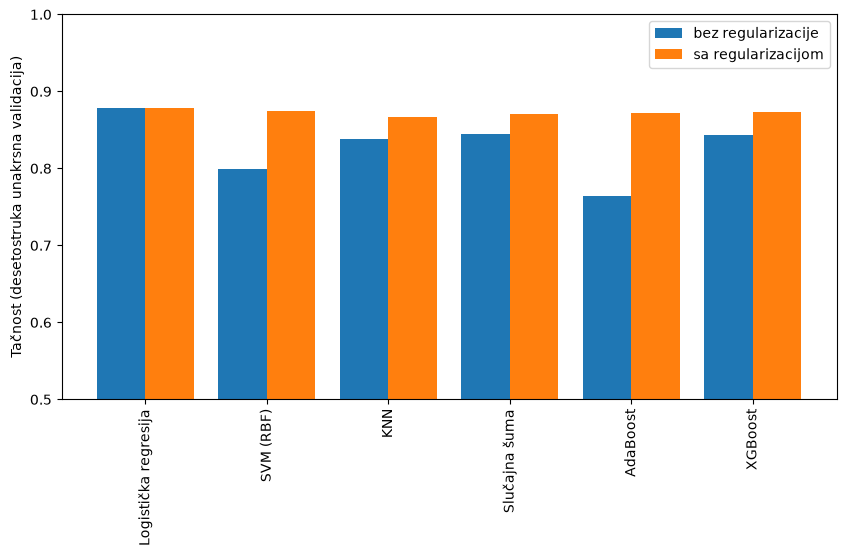

In [104]:
plt.figure(figsize=(10, 5))
plt.bar(np.arange(6) - 0.2, accuracy_bez, width=0.4, label='bez regularizacije')
plt.bar(np.arange(6) + 0.2, accuracy_sa, width=0.4, label='sa regularizacijom')
plt.xticks(np.arange(6), modeli_bez_regularizacije.keys(), rotation='vertical')
plt.ylabel('Tačnost (desetostruka unakrsna validacija)')
plt.ylim(0.5, 1.0)
plt.legend(loc='best')
plt.show()

Razlika između dve varijante je najveća kod SVM-a i AdaBoost-a, koji su bili najfleksibilniji. Kod logističke regresije razlike nema, jer je izabrano <code>C</code> = 1, za koje je model isti kao onaj bez kazne.

# Zaključak

Modeli bez regularizacije se izrazito preprilagođavaju. Pet od šest ima tačnost 1.00 na skupu za treniranje, a na neviđenim podacima su znatno slabiji. Regularizacija popravlja svaki od šest algoritama. Metaparametre smo birali na dva načina, pomoću validacionog skupa (logistička regresija, SVM, KNN) i unakrsnom validacijom pomoću klase <code>GridSearchCV</code> (slučajna šuma, AdaBoost, XGBoost). Ocene modela sa regularizacijom su blago optimistične, jer su metaparametri birani nad istim podacima.
